# **AI Agent 기본 패턴**

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `ai_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!pip install langchain-openai langchain_community -q

* 라이브러리 로딩

In [ ]:
import pandas as pd
import numpy as np
import os
import openai

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState

### (3) OpenAI API Key 확인

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "="     in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/ai_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ api_key가 잘 등록되었는지 확인

In [ ]:
print(os.environ['OPENAI_API_KEY'][:40])

## **2. 패턴① : Routing**

### **(1) 간단한 Rounting 패턴 만들기**

* 고객 요청사항을 접수 받아
    * 신규 가입이면 ➡ new_member agent로
    * 그 외 문의사항 ➡ customer_servise agent
* 각 처리 후 종료

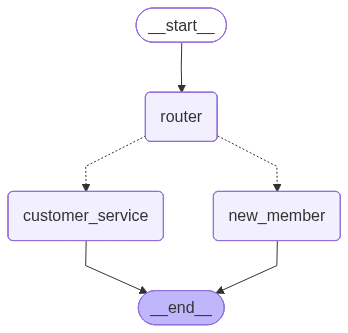

#### **1) State 정의 및 llm 준비**

In [ ]:
class SimpleState(MessagesState):
    next_agent: str
    response: str

In [ ]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

#### **2) Node 준비**

* 접수 Agent

In [ ]:
def CS_agent(state: SimpleState):
    # 1. State에서 필요한 정보 저장
    prompt = state["messages"][0].content

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할
    너는 고객 요청사항 접수 담당 에이전트야.

    # 지침
    - 고객 요청사항을 받아서 담당자를 지정해.
    - 신규가입 건 : new_member
    - 그 외 문의 건 : customer_service

    # 출력 형식
    - new_member 혹은 customer_service 둘 중 하나만 출력해
    - 이 둘 외의 다른 답변을 달지 마.
    ''')
    hu_msg = HumanMessage(prompt)

    # 3. llm 호출
    result = llm.invoke([sys_msg, hu_msg])

    # 4. state 업데이트
    return {"messages": result, "next_agent": result.content}

* 조치 에이전트

In [ ]:
# 신규 가입 agent
def new_member(state: SimpleState):
    # 1. State에서 필요한 정보 저장

    # 2. prompt 구성

    # 3. llm 호출
    result = AIMessage('요청하신 신규 가입 건이 처리 되었습니다.')

    # 4. state 업데이트
    return {"messages": result, "response": result.content}


# 일반 지원 agent
def customer_service(state: SimpleState):
    # 1. State에서 필요한 정보 저장

    # 2. prompt 구성

    # 3. llm 호출
    result = AIMessage('요청하신 요청 건이 처리 되었습니다.')

    # 4. state 업데이트
    return {"messages": result, "response": result.content}

* 조건 분기 함수

In [ ]:
def condition(state: SimpleState):
    next_agent = state['next_agent']
    return next_agent

#### **3) 그래프 구성**

In [ ]:
# 그래프 생성
builder = StateGraph(SimpleState)

# 노드 등록
builder.add_node("router", CS_agent)
builder.add_node("new_member", new_member)
builder.add_node("customer_service", customer_service)

# 조건 분기 연결
builder.add_conditional_edges("router", condition,
                              {"new_member": "new_member",
                               "customer_service": "customer_service"})

# 나머지 연결
builder.add_edge(START, "router")
builder.add_edge("new_member", END)
builder.add_edge("customer_service", END)

# 그래프 컴파일
graph = builder.compile()

* 그래프 시각화

In [ ]:
graph

#### **4) Graph 실행**

In [ ]:
initial_state = {"messages": "새로 회원가입하고 싶어요"}

result = graph.invoke(initial_state)

for m in result["messages"]:
    m.pretty_print()

### **(2) 실습1🔥**

* (1)에서 다음 항목을 개선해 봅시다.
    * customer_service, new_member에서 llm이 답변하도록 구성
    * customer_service, new_member의 답변을 다듬어서 최종 답변을 생성하는 final_agent 노드 추가
    * 최종 답변을 담을 수 있도록 state에 키 추가

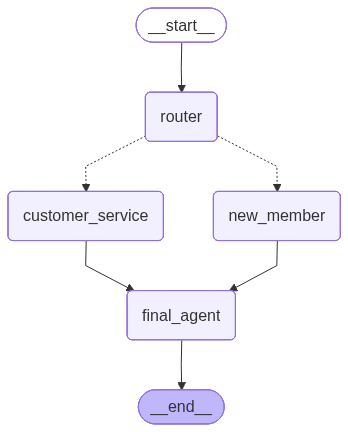

#### **1) State 정의 및 llm 준비**

In [ ]:
class CS_State(MessagesState):
    next_agent: str
    response: str
    final_resp: str

In [ ]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

#### **2) Node 준비**

* 접수 Agent

In [ ]:
def CS_agent(state: CS_State):
    # 1. State에서 필요한 정보 저장
    # user_input = state["messages"][0].content 형태로 가져오세요.


    # 2. prompt 구성
    # SystemMessage: 담당자를 지정하는 라우팅 규칙 안내 (new_member / customer_service)
    # HumanMessage: user_input 전달


    # 3. llm 호출
    # llm.invoke([sys_msg, hu_msg])


    # 4. state 업데이트
    # {"messages": 결과, "next_agent": 결과.content} 형태로 반환하세요.


* 조치 에이전트
    * 다음 에이전트에서 llm이 답변하도록 수정하세요.

In [ ]:
# 신규 가입 agent
def new_member(state: CS_State):
    # 1. State에서 필요한 정보 저장
    user_input = state["messages"][0].content

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할 : (여기에 신규 가입 처리 에이전트 역할을 작성하세요)
    # 지침 : (여기에 답변 지침을 작성하세요)
    ''')
    hu_msg = HumanMessage(user_input)

    # 3. llm 호출
    result = llm.invoke([sys_msg, hu_msg])

    # 4. state 업데이트
    return {"messages": result, "response": result.content}


In [ ]:
# 일반 지원 agent
def customer_service(state: CS_State):
    # 1. State에서 필요한 정보 저장
    user_input = state["messages"][0].content

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할 : (여기에 일반 문의 처리 에이전트 역할을 작성하세요)
    # 지침 : (여기에 답변 지침을 작성하세요)
    ''')
    hu_msg = HumanMessage(user_input)

    # 3. llm 호출
    result = llm.invoke([sys_msg, hu_msg])

    # 4. state 업데이트
    return {"messages": result, "response": result.content}


* 최종 답변 생성 agent
    * 최종 답변을 생성하는 에이전트 구성

In [ ]:
def final_agent(state: CS_State):
    # 1. State에서 필요한 정보 저장
    # response = state["response"] 형태로 가져오세요.


    # 2. prompt 구성
    # SystemMessage: 담당 에이전트의 답변을 다듬어 최종 답변으로 정리하는 역할 지정
    # HumanMessage: response 전달


    # 3. llm 호출
    # llm.invoke([sys_msg, hu_msg])


    # 4. state 업데이트
    # {"messages": 결과, "final_resp": 결과.content} 형태로 반환하세요.


* 조건 분기 함수

In [ ]:
def condition(state: CS_State):
    next_agent = state['next_agent']
    return next_agent

#### **3) 그래프 구성**
* 기존 그래프를 수정하세요.

In [ ]:
# 그래프 생성


# 노드 등록


# 조건 분기 연결


# 나머지 연결


# 그래프 컴파일


* 그래프 시각화

In [ ]:
graph

#### **4) Graph 실행**

In [ ]:
initial_state = {"messages": "새로 회원가입하고 싶어요"}

result = graph.invoke(initial_state)

for m in result["messages"]:
    m.pretty_print()

### **(3) 실습2🔥**

* 실습1에 노드 하나를 추가합시다.
* 고객 요청사항을 접수 받아
    * 신규 가입 ➡ new_member agent로
    * **환불 문의 ➡ refund agent로**
    * 그 외 문의사항 ➡ customer_servise agent
* 각 처리 결과를 검토해서 다듬고 종료

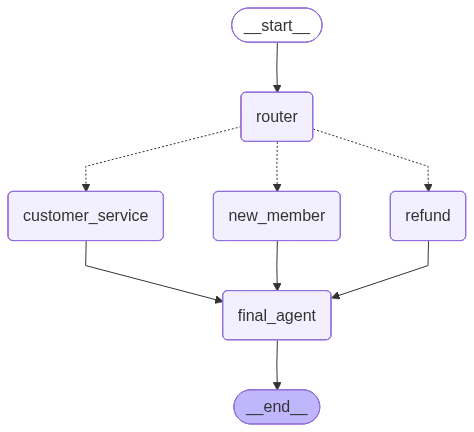

#### **1) State 정의 및 llm 준비**

In [ ]:
class CS_State(MessagesState):
    # 실습1의 CS_State를 참고해서 필요한 필드를 정의하세요.
    # next_agent, response, final_resp


#### **2) Node 준비**

* 접수 Agent
    * 환불 에이전트를 고려하도록 수정

In [ ]:
def CS_agent(state: CS_State):
    # 1. State에서 필요한 정보 저장
    # user_input = state["messages"][0].content


    # 2. prompt 구성
    # SystemMessage: 담당자를 지정하는 라우팅 규칙
    # - 신규가입 : new_member
    # - 환불 문의 : refund
    # - 그 외 : customer_service
    # HumanMessage: user_input 전달


    # 3. llm 호출


    # 4. state 업데이트
    # {"messages": 결과, "next_agent": 결과.content} 형태로 반환하세요.


* 조치 에이전트
    * 환불 에이전트 추가

In [ ]:
# 환불 agent
def refund(state: CS_State):
    # 1. State에서 필요한 정보 저장
    # user_input = state["messages"][0].content


    # 2. prompt 구성
    # SystemMessage: 환불 요청을 처리하는 에이전트 역할과 안내할 정보(주문번호, 환불 사유 등) 지정
    # HumanMessage: user_input 전달


    # 3. llm 호출


    # 4. state 업데이트
    # {"messages": 결과, "response": 결과.content} 형태로 반환하세요.


In [ ]:
# 신규 가입 agent
def new_member(state: CS_State):
    # 1. State에서 필요한 정보 저장
    user_input = state["messages"][0].content

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할 : (여기에 신규 가입 처리 에이전트 역할을 작성하세요)
    # 지침 : (여기에 답변 지침을 작성하세요)
    ''')
    hu_msg = HumanMessage(user_input)

    # 3. llm 호출
    result = llm.invoke([sys_msg, hu_msg])

    # 4. state 업데이트
    return {"messages": result, "response": result.content}


In [ ]:
# 일반 지원 agent
def customer_service(state: CS_State):
    # 1. State에서 필요한 정보 저장
    user_input = state["messages"][0].content

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할 : (여기에 일반 문의 처리 에이전트 역할을 작성하세요)
    # 지침 : (여기에 답변 지침을 작성하세요)
    ''')
    hu_msg = HumanMessage(user_input)

    # 3. llm 호출
    result = llm.invoke([sys_msg, hu_msg])

    # 4. state 업데이트
    return {"messages": result, "response": result.content}


* 최종 답변 생성 agent

In [ ]:
def final_agent(state: CS_State):
    # 1. State에서 필요한 정보 저장
    # response = state["response"] 형태로 가져오세요.


    # 2. prompt 구성
    # SystemMessage: 담당 에이전트의 답변을 다듬어 최종 답변으로 정리하는 역할 지정
    # HumanMessage: response 전달


    # 3. llm 호출


    # 4. state 업데이트
    # {"messages": 결과, "final_resp": 결과.content} 형태로 반환하세요.


* 조건 분기 함수

In [ ]:
def condition(state: CS_State):
    next_agent = state['next_agent']
    return next_agent

#### **3) 그래프 구성**

In [ ]:
# 그래프 생성


# 노드 등록

# 조건 분기 연결

# 나머지 연결


# 그래프 컴파일


* 그래프 시각화

In [ ]:
graph

#### **4) Graph 실행**

In [ ]:
initial_state = {"messages": "어제 구매한 마우스 주문 취소하고 환불해 주세요"}

result = graph.invoke(initial_state)

for m in result["messages"]:
    m.pretty_print()

어제 구매하신 마우스의 **주문 취소 및 환불 처리**를 도와드리겠습니다!

**[조치1] 주문 취소 및 환불 진행**
요청을 접수하였으며, 확인 즉시 처리해 드리겠습니다.

---

원활한 처리를 위해 아래 정보를 알려주시겠어요? 😊
- 📋 **주문 번호**
- 👤 **구매자 성함 / 연락처**

## **3. 패턴② : Loop**

### **(1) 간단한 Loop 패턴 만들기**

* 문서(긴 문장)를 입력받아
* 요약한 후
* 검토하여
    * 적합 : 종료
    * 부적합 : 다시 요약

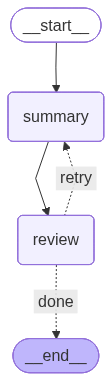

#### **1) State 정의 및 llm 준비**

In [ ]:
class SummaryState(MessagesState):
    input_text: str         # 원본 입력
    summary: str        # 요약된 문장
    satisfied: str       # 요약 결과 평가 : 적합, 부적합
    loop_count: int       # 반복횟수

In [ ]:
llm_summary = ChatOpenAI(model="gpt-4.1-mini", temperature = 0.5)
llm_review = ChatOpenAI(model="gpt-4.1-mini", temperature = 0.1)

#### **2) Node 준비**

* 요약 Agent

In [ ]:
def summary_agent(state: SummaryState):
    # 1. State에서 필요한 정보 저장
    prompt = state["input_text"]
    curr_count = state["loop_count"]

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할
    너는 입력받은 내용을 요약하는 에이전트야.

    # 지침
    - 간결하게 3가지 항목으로 요약해.

    # 출력 형식
    - Bullet-point
    ''')
    hu_msg = HumanMessage(prompt)

    # 3. llm 호출
    result = llm_summary.invoke([sys_msg, hu_msg])

    # 4. state 업데이트
    return {"messages": result, "summary": result.content, 'loop_count':curr_count+1}

* 검토 에이전트

In [ ]:
def review_agent(state: SummaryState):
    # 1. State에서 필요한 정보 저장

    # 2. prompt 구성

    # 3. llm 호출
    result = AIMessage('부적합')

    # 4. state 업데이트
    return {"messages": result, "satisfied": result.content}

* 조건 분기 함수
    * 부적합

In [ ]:
def condition(state: SummaryState):
    satisfied = state['satisfied']
    curr_count = state["loop_count"]

    # 적합 이거나, 재시도 횟수가 2을 초과하면 done
    if (satisfied == '적합') or (curr_count > 2):
        next_step = 'done'
    else :
        next_step = 'retry'

    return next_step

#### **3) 그래프 구성**

In [ ]:
# 초기화
builder = StateGraph(SummaryState)

# 2.노드추가
builder.add_node("summary", summary_agent)
builder.add_node("review", review_agent)

# 3.연결
builder.add_edge(START, "summary")
builder.add_edge("summary", "review")

builder.add_conditional_edges("review", condition, {"done": END, "retry": "summary"} )

# 4. 컴파일
graph = builder.compile()

* 그래프 시각화

In [ ]:
graph

* Graph 실행

In [ ]:
# 실행
text = '''
LangGraph는 LLM 기반 애플리케이션을 그래프(Graph) 구조와 상태(State) 관리 방식으로 설계하는 프레임워크이다.
기존의 단순한 체인 방식(입력 → LLM → 출력)을 넘어, 여러 에이전트가 협업하고 조건에 따라 분기하거나 반복 수행하는 복잡한 흐름을 구현할 수 있다.
각 작업 단위는 노드(Node)로 정의되고, 노드 간 연결은 엣지(Edge)로 표현되며, 모든 노드는 공유 상태(State)를 읽고 수정하면서 작업을 이어간다.

특히 LangGraph는 멀티 에이전트(Multi-Agent), 반복 루프, Human-in-the-Loop(HITL), 체크포인트 기반 상태 저장을 자연스럽게 지원한다.
이를 통해 Planner–Executor–Critic 구조, Supervisor 패턴, Router 패턴과 같은 에이전트 아키텍처를 쉽게 구현할 수 있으며,
실행 중 상태 추적과 재시작, 디버깅까지 가능하다.
따라서 LangGraph는 단순한 프롬프트 연결 도구가 아니라, AI 에이전트의 전체 실행 흐름을 설계하고 운영하는 프레임워크로 활용된다.
'''

initial_state = {"messages": text ,
                 "input_text": text, "loop_count": 0}

result = graph.invoke(initial_state)

In [ ]:
print(result['summary'])
print(result['loop_count'])

In [ ]:
for m in result["messages"]:
    m.pretty_print()

### **(2) 실습🔥**
이전 loop 패턴 에이전트를 개선해 봅시다.

* 검토(review) 에이전트에서 LLM이 검토후 재작업 판단
    * 현재 : 무조건 부적합 판정
    * 수정 : llm이 원문과 요약문을 보고 적절한지 판단

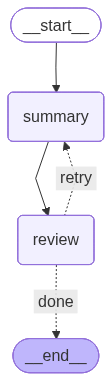

#### **1) State 정의 및 llm 준비**

In [ ]:
class SummaryState(MessagesState):
    input_text: str         # 원본 입력
    summary: str        # 요약된 문장
    satisfied: str       # 요약 결과 평가 : 적합, 부적합
    loop_count: int       # 반복횟수

In [ ]:
llm_summary = ChatOpenAI(model="gpt-4.1-mini", temperature = 0.5)
llm_review = ChatOpenAI(model="gpt-4.1-mini", temperature = 0.1)

#### **2) Node 준비**

* 요약 Agent

In [ ]:
def summary_agent(state: SummaryState):
    # 1. State에서 필요한 정보 저장
    # input_text = state["input_text"]
    # curr_count = state["loop_count"]


    # 2. prompt 구성
    # SystemMessage: 입력받은 내용을 요약하는 에이전트 역할과 출력 형식(Bullet-point 등) 지정
    # HumanMessage: input_text 전달


    # 3. llm 호출
    # llm_summary.invoke([sys_msg, hu_msg])


    # 4. state 업데이트
    # {"messages": 결과, "summary": 결과.content, "loop_count": curr_count + 1} 형태로 반환하세요.


* 검토 에이전트

In [ ]:
def review_agent(state: SummaryState):
    # 1. State에서 필요한 정보 저장
    # input_text = state["input_text"]
    # summary = state["summary"]


    # 2. prompt 구성
    # SystemMessage: 원문과 요약문을 비교해서 요약이 적절한지 "적합" 또는 "부적합"으로만 판단하도록 지정
    # HumanMessage: input_text와 summary를 함께 전달


    # 3. llm 호출
    # llm_review.invoke([sys_msg, hu_msg])


    # 4. state 업데이트
    # {"messages": 결과, "satisfied": 결과.content} 형태로 반환하세요.


* 조건 분기 함수
    * 부적합

In [ ]:
def condition(state: SummaryState):
    satisfied = state['satisfied']
    curr_count = state["loop_count"]

    # 적합 이거나, 재시도 횟수가 2을 초과하면 done
    if (satisfied == '적합') or (curr_count > 2):
        next_step = 'done'
    else :
        next_step = 'retry'

    return next_step

#### **3) 그래프 구성**

In [ ]:
# 1. 초기화


# 2.노드추가


# 3.연결


# 4. 컴파일


* 그래프 시각화

In [ ]:
graph

* Graph 실행

In [ ]:
# 실행
text = '''
LangGraph는 LLM 기반 애플리케이션을 그래프(Graph) 구조와 상태(State) 관리 방식으로 설계하는 프레임워크이다.
기존의 단순한 체인 방식(입력 → LLM → 출력)을 넘어, 여러 에이전트가 협업하고 조건에 따라 분기하거나 반복 수행하는 복잡한 흐름을 구현할 수 있다.
각 작업 단위는 노드(Node)로 정의되고, 노드 간 연결은 엣지(Edge)로 표현되며, 모든 노드는 공유 상태(State)를 읽고 수정하면서 작업을 이어간다.

특히 LangGraph는 멀티 에이전트(Multi-Agent), 반복 루프, Human-in-the-Loop(HITL), 체크포인트 기반 상태 저장을 자연스럽게 지원한다.
이를 통해 Planner–Executor–Critic 구조, Supervisor 패턴, Router 패턴과 같은 에이전트 아키텍처를 쉽게 구현할 수 있으며,
실행 중 상태 추적과 재시작, 디버깅까지 가능하다.
따라서 LangGraph는 단순한 프롬프트 연결 도구가 아니라, AI 에이전트의 전체 실행 흐름을 설계하고 운영하는 프레임워크로 활용된다.
'''

initial_state = {"input_text": text, "loop_count": 0}

result = graph.invoke(initial_state)

In [ ]:
print(result['summary'])
print(result['loop_count'])

In [ ]:
for m in result["messages"]:
    m.pretty_print()

### **(3) 실습🔥**
이전 loop 패턴 에이전트를 개선해 봅시다.

* 검토(review) 에이전트에서 LLM이 검토후 재작업 판단
    * 현재 : 무조건 부적합 판정
    * 수정 : llm이 원문과 요약문을 보고 적절한지 판단, 판단 근거 포함

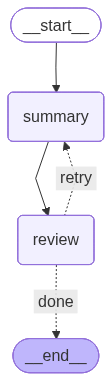

#### **1) State 정의 및 llm 준비**

In [ ]:
class SummaryState(MessagesState):
    input_text: str         # 원본 입력
    summary: str        # 요약된 문장
    satisfied: str       # 요약 결과 평가 : 적합, 부적합
    reason: str         # 판정 근거 1문장
    loop_count: int       # 반복횟수

In [ ]:
llm_summary = ChatOpenAI(model="gpt-4.1-mini", temperature = 0.5)
llm_review = ChatOpenAI(model="gpt-4.1-mini", temperature = 0.1)

#### **2) Node 준비**

* 요약 Agent

In [ ]:
def summary_agent(state: SummaryState):
    # 1. State에서 필요한 정보 저장
    # input_text = state["input_text"]
    # curr_count = state["loop_count"]


    # 2. prompt 구성
    # SystemMessage: 입력받은 내용을 요약하는 에이전트 역할과 출력 형식(Bullet-point 등) 지정
    # HumanMessage: input_text 전달


    # 3. llm 호출
    # llm_summary.invoke([sys_msg, hu_msg])


    # 4. state 업데이트
    # {"messages": 결과, "summary": 결과.content, "loop_count": curr_count + 1} 형태로 반환하세요.


* 검토 에이전트

In [ ]:
def review_agent(state: SummaryState):
    # 1. State에서 필요한 정보 저장
    # input_text = state["input_text"]
    # summary = state["summary"]


    # 2. prompt 구성
    # SystemMessage: 원문과 요약문을 비교해서 "적합"/"부적합" 판단과 판단 근거(reason)를 함께 출력하도록 지정
    #   예: 판단과 근거를 구분자로 나눠서 출력하도록 형식을 정해주세요.
    # HumanMessage: input_text와 summary를 함께 전달


    # 3. llm 호출
    # llm_review.invoke([sys_msg, hu_msg])


    # 4. state 업데이트
    # {"messages": 결과, "satisfied": ..., "reason": ...} 형태로 반환하세요.
    # (satisfied와 reason을 결과 텍스트에서 분리하는 방법을 고민해보세요)


* 조건 분기 함수
    * 부적합

In [ ]:
def condition(state: SummaryState):
    satisfied = state['satisfied']
    curr_count = state["loop_count"]

    # 적합 이거나, 재시도 횟수가 2을 초과하면 done
    if (satisfied == '적합') or (curr_count > 2):
        next_step = 'done'
    else :
        next_step = 'retry'

    return next_step


#### **3) 그래프 구성**

In [ ]:
# 1.초기화


# 2.노드추가


# 3.연결


# 4. 컴파일


* 그래프 시각화

In [ ]:
graph

* Graph 실행

In [ ]:
# 실행
text = '''
LangGraph는 LLM 기반 애플리케이션을 그래프(Graph) 구조와 상태(State) 관리 방식으로 설계하는 프레임워크이다.
기존의 단순한 체인 방식(입력 → LLM → 출력)을 넘어, 여러 에이전트가 협업하고 조건에 따라 분기하거나 반복 수행하는 복잡한 흐름을 구현할 수 있다.
각 작업 단위는 노드(Node)로 정의되고, 노드 간 연결은 엣지(Edge)로 표현되며, 모든 노드는 공유 상태(State)를 읽고 수정하면서 작업을 이어간다.

특히 LangGraph는 멀티 에이전트(Multi-Agent), 반복 루프, Human-in-the-Loop(HITL), 체크포인트 기반 상태 저장을 자연스럽게 지원한다.
이를 통해 Planner–Executor–Critic 구조, Supervisor 패턴, Router 패턴과 같은 에이전트 아키텍처를 쉽게 구현할 수 있으며,
실행 중 상태 추적과 재시작, 디버깅까지 가능하다.
따라서 LangGraph는 단순한 프롬프트 연결 도구가 아니라, AI 에이전트의 전체 실행 흐름을 설계하고 운영하는 프레임워크로 활용된다.
'''

initial_state = {"input_text": text, "loop_count": 0}

result = graph.invoke(initial_state)

In [ ]:
print(result['summary'])
print('='*100)
print(result['reason'])
print('='*100)
print(result['loop_count'])

In [ ]:
for m in result["messages"]:
    m.pretty_print()

## **4. 추가 연습 문제🔥**

업무 흐름 : 업무 이메일을 수신하면 → 유형 분류(Routing) → 초안 작성 → 품질 검토(Loop) → 최종 답변

        [입력] 이메일 내용  
            ↓  
        [router] 이메일 유형 분류  
            ├─ "문의" → inquiry  (문의 답변 초안 작성)  
            └─ "불만" → complaint (불만 처리 초안 작성)  
                ↓  
        [review] 초안 품질 검토 (LLM 판단)  
            ├─ "적합" → END  
            └─ "부적합" → 다시 초안 작성 (최대 3회)  

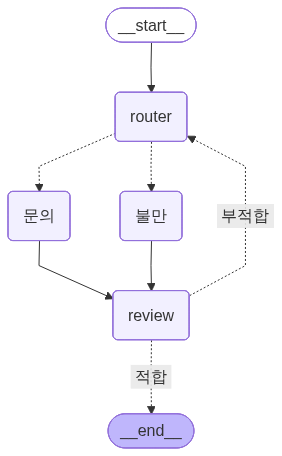

> ⚠️ **이 실습의 핵심 포인트**
>
> Routing과 Loop, 두 패턴을 **하나의 그래프에서 결합**합니다.
> 한 번에 완성하려 하지 말고, 아래 **2단계**로 나눠 진행합니다.
>
> | | 목표 | 그래프 구조 |
> |---|---|---|
> | **1단계** | Routing만 동작 확인 | START → router → 문의/불만 → END |
> | **2단계** | Loop 추가해서 전체 완성 | 1단계 + review → 적합/부적합 분기 |


> 💡 **State 필드 — 미리 파악하고 시작하세요**
>
> | 필드 | router | inquiry / complaint | review |
> |---|---|---|---|
> | `messages` | R/W | R/W | R/W |
> | `email_type` | W | R | - |
> | `draft` | - | W | R |
> | `loop_count` | - | - | R/W |

### **1단계 : Routing 완성하기**

* Routing 패턴만 먼저 완성합니다.
* 그래프 구조 : `START → router → 문의/불만 → END`

> 💡 **힌트 — `email_type` 흐름**
> - `router` 노드가 LLM 결과(`"문의"` or `"불만"`)를 `email_type` 필드에 저장
> - `route_by_type` 조건 분기 함수는 `state["email_type"]`을 그대로 반환하면 됨

(20분 소요)

#### **(1) State 정의**

In [ ]:
class EmailState(MessagesState):
    # 1단계에 필요한 필드를 정의하세요.
    # email_type: str   # router가 분류한 이메일 유형 ("문의" 또는 "불만")
    # draft: str         # inquiry/complaint가 작성한 답변 초안


In [ ]:
# llm 인스턴스를 준비하세요.
# 예 : llm = ChatOpenAI(model = "gpt-4.1-mini")


#### **(2) Node 준비**

In [ ]:
# Router 노드
def router(state: EmailState):
    # 1. State에서 필요한 정보 저장
    # user_input = state["messages"][0].content


    # 2. prompt 구성
    # SystemMessage: 이메일 내용을 보고 "문의" 또는 "불만" 중 하나로만 분류하도록 지정
    # HumanMessage: user_input 전달


    # 3. llm 호출


    # 4. state 업데이트
    # {"messages": 결과, "email_type": 결과.content} 형태로 반환하세요.


In [ ]:
# 문의 처리 노드
def inquiry(state: EmailState):
    # 1. State에서 필요한 정보 저장
    user_input = state["messages"][0].content

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할 : (여기에 문의 이메일에 대한 답변 초안을 작성하는 에이전트 역할을 작성하세요)
    # 지침 : (여기에 답변 지침을 작성하세요)
    ''')
    hu_msg = HumanMessage(user_input)

    # 3. llm 호출
    result = llm.invoke([sys_msg, hu_msg])

    # 4. state 업데이트
    return {"messages": result, "draft": result.content}


In [ ]:
# 불만 처리 노드
def complaint(state: EmailState):
    # 1. State에서 필요한 정보 저장
    user_input = state["messages"][0].content

    # 2. prompt 구성
    sys_msg = SystemMessage('''
    # 역할 : (여기에 불만 이메일에 대한 답변 초안을 작성하는 에이전트 역할을 작성하세요)
    # 지침 : (여기에 답변 지침을 작성하세요)
    ''')
    hu_msg = HumanMessage(user_input)

    # 3. llm 호출
    result = llm.invoke([sys_msg, hu_msg])

    # 4. state 업데이트
    return {"messages": result, "draft": result.content}


#### **(3) 그래프 구성 — 1단계**

In [ ]:
# 이메일 유형에 따라 분기
def route_by_type(state: EmailState):
    # state["email_type"] 값을 그대로 반환하세요.


In [ ]:
# 1. 초기화


# 2.노드추가


# 3.연결


# 4. 컴파일


#### **(4) 실행 — 1단계**

In [ ]:
email_1 = '''
안녕하세요.
이번 달 청구서에 지난달과 다른 금액이 청구되어 문의드립니다.
지난달에는 50,000원이었는데 이번 달은 75,000원으로 확인됩니다.
요금이 변경된 사유가 있다면 안내 부탁드립니다.
감사합니다.
'''

initial_state = {"messages": [HumanMessage(email_1)]}
result = graph_step1.invoke(initial_state)

In [ ]:
for m in result["messages"]:
    m.pretty_print()

### **2단계 : Loop 추가해서 전체 완성하기**

* `review` 노드와 `route_by_review` 분기 함수를 추가하여 전체 흐름을 완성합니다.
* 그래프 구조 : `START → router → 문의/불만 → review → 적합/부적합 분기`

> 💡 **힌트 — `loop_count` 관리**
> - `review` 노드에서 `loop_count + 1` 해서 State에 저장
> - `route_by_review` 에서 `loop_count >= 3` 이면 강제 종료
> - `state.get("loop_count", 0)` 으로 초기값이 없어도 안전하게 읽기

In [ ]:
class EmailState(MessagesState):
    # 1단계 필드에 loop_count를 추가하세요.
    # email_type: str
    # draft: str
    # loop_count: int


#### **(1) review 노드 추가**

In [ ]:
# 검토 노드
def review(state: EmailState):
    # 1. State에서 필요한 정보 저장
    # draft = state["draft"]
    # curr_count = state.get("loop_count", 0)


    # 2. prompt 구성
    # SystemMessage: 이메일 답변 초안이 적절한지 "적합" 또는 "부적합"으로 판단하도록 지정
    # HumanMessage: draft 전달


    # 3. llm 호출


    # 4. state 업데이트
    # {"messages": 결과, "satisfied": 결과.content, "loop_count": curr_count + 1} 형태로 반환하세요.


#### **(2) 그래프 구성 — 2단계 (전체 완성)**

In [ ]:
# 이메일 유형에 따라 분기 (1단계와 동일)
def condition1(state: EmailState):
    # state["email_type"] 값을 그대로 반환하세요. (1단계에서 작성한 route_by_type과 동일한 로직)


In [ ]:
# 검증/시도횟수에 따른 분기
def condition2(state: EmailState):
    # satisfied와 loop_count를 확인해서
    # "적합"이거나 loop_count가 3 이상이면 "done", 아니면 "retry"를 반환하세요.
    # (Loop 실습의 condition 함수 구조를 참고하세요)


In [ ]:
# 1. 초기화


# 2.노드추가


# 3.연결


# 4. 컴파일


#### **(3) 실행 — 2단계**

In [ ]:
initial_state = {"messages": [HumanMessage(email_1)]}
result = graph.invoke(initial_state)

In [ ]:
for m in result["messages"]:
    m.pretty_print()